In [ ]:
!pip install -q accelerate -U
!pip install -q bitsandbytes -U
!pip install -q trl -U
!pip install -q peft -U
!pip install -q transformers -U
!pip install -q datasets -U
!pip install bitsandbytes --prefer-binary --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import pandas as pd
from datasets import load_dataset, Dataset, DatasetDict

df = pd.read_csv("/content/Follow_Up_Dataset.csv")
df = df.dropna()

In [ ]:
df.head()

,question,answer,follow-up questions
0,What did objects in forced motion contain acco...,impetus,How did the concept of impetus lead to the rej...
1,What was thought to decide a person's behavior?,the environment in which they lived,How did the four humors influence behavior?;Wh...
2,What makes the method of trial division more e...,if a complete list of primes up to is known,What are the limitations of trial division?;Ho...
3,What makes up 74% of the sun's mass?,"Based on scientific knowledge, hydrogen makes ...",How do scientists determine the Sun’s composit...
4,Why does hydrogen make up the majority of the ...,Hydrogen makes up the majority of the Sun’s ma...,Why doesn’t the Sun run out of hydrogen quickl...


In [ ]:
df["question"].value_counts()

,count
question,
How many bodies of water makes up Lake Constance?,2
Where does heat rejection occur in the Rankine cycle?,2
What did the Jewish people do so pagan items wouldn't be in the temple of Jerusalem?,1
"Assuming the Air Force paid for the development of the concept, then would the Air Force be entitled to a royalty fee for every packet sent?",1
What Fields Medal winning Mathematician is a faculty member at Harvard?,1
...,...
"Did Baran develop this ""only"" for use by the Air Force?",1
What usually carries sediment particles from one place to another?,1
What did the Velvet revolution hope to accomplish in India?,1


In [ ]:
df['text'] = "\nAnswer: " + df['answer'] + "\n\nFollow Up Question: " + df['follow-up questions']

In [ ]:
print(df['text'][0])


Answer: impetus

Follow Up Question: How did the concept of impetus lead to the rejection of Aristotle's theory of motion?;What were the key differences between impetus theory and Newton’s first law of motion?;Why was Aristotle’s original explanation of motion considered insufficient by later medieval scholars?


In [ ]:
df = df[['question', 'text']]

In [ ]:
df.head()

,question,text
0,What did objects in forced motion contain acco...,\nAnswer: impetus\n\nFollow Up Question: How d...
1,What was thought to decide a person's behavior?,\nAnswer: the environment in which they lived\...
2,What makes the method of trial division more e...,\nAnswer: if a complete list of primes up to ...
3,What makes up 74% of the sun's mass?,"\nAnswer: Based on scientific knowledge, hydro..."
4,Why does hydrogen make up the majority of the ...,\nAnswer: Hydrogen makes up the majority of th...


In [ ]:
dataset = Dataset.from_pandas(df)
dataset = dataset.shuffle(seed=0)
dataset = dataset.train_test_split(test_size=0.1)

In [ ]:
dataset['test'][0]

{'question': 'How wide is the glacial alpine valley known as the Rhine Valley?',
 'text': "\nAnswer: The Rhine Valley (or Upper Rhine Graben) varies in width, but in the section known as the Upper Rhine Valley, it is approximately 30 to 40 kilometers (18 to 25 miles) wide. This glacial alpine valley stretches between the Black Forest and the Vosges mountains.\n\nFollow Up Question: How did glaciers contribute to the formation of the Rhine Valley?; What are the geographical features surrounding the Rhine Valley?; How has the Rhine Valley's width impacted human settlement and agriculture?; What role does the Rhine River play in the valley’s ecosystem?; How does the Rhine Valley’s formation compare to other glacial valleys?"}

In [ ]:
dummy = df.copy()
dummy['question_tokens'] = dummy['question'].apply(lambda x: len(x.split())*1.5)
dummy['text_tokens'] = dummy['text'].apply(lambda x: len(x.split())*1.5)

<Axes: >

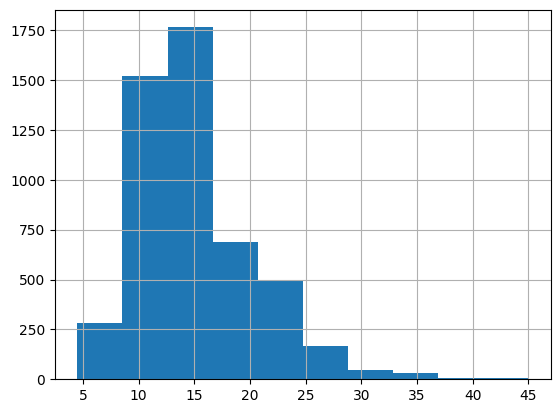

In [ ]:
dummy['question_tokens'].hist()

<Axes: >

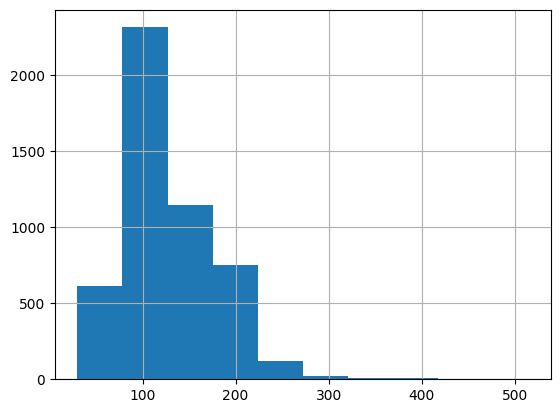

In [ ]:
dummy['text_tokens'].hist()

In [ ]:
del dummy

In [ ]:
def formatting_func(example):
    text = f"""
Given the Question of a topic, you need to generate answer and follow up questions of this topic.
### Question: {example['question']}
### Result: {example['text']}
"""
    return text

In [ ]:
print(formatting_func(dataset['test'][0]))


Given the Question of a topic, you need to generate answer and follow up questions of this topic.
### Question: How wide is the glacial alpine valley known as the Rhine Valley?
### Result: 
Answer: The Rhine Valley (or Upper Rhine Graben) varies in width, but in the section known as the Upper Rhine Valley, it is approximately 30 to 40 kilometers (18 to 25 miles) wide. This glacial alpine valley stretches between the Black Forest and the Vosges mountains.

Follow Up Question: How did glaciers contribute to the formation of the Rhine Valley?; What are the geographical features surrounding the Rhine Valley?; How has the Rhine Valley's width impacted human settlement and agriculture?; What role does the Rhine River play in the valley’s ecosystem?; How does the Rhine Valley’s formation compare to other glacial valleys?



In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

base_model_id = "microsoft/phi-2"

model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    load_in_8bit=True,
    device_map='auto',
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors.index.json:   0%|          | 0.00/35.7k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    padding_size='left',
    add_eos_token=True,
    add_bos_token=True,
    use_fast=False
)

tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

In [ ]:
max_length = 100

def tokenize(prompt):
    result = tokenizer(
        formatting_func(prompt),
        truncation=True,
        max_length=max_length,
        padding="max_length"
    )

    result['labels'] = result['input_ids'].copy()

    return result

In [ ]:
dataset = dataset.map(tokenize)

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
from peft import LoraConfig, get_peft_model

target_modules = ["Wqvk", "fc1", "fc2"]

config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=target_modules,
    bias = 'none',
    lora_dropout=0.05,
    task_type = 'CAUSAL_LM'
)

model = get_peft_model(model, config)

In [ ]:
def print_trainable_parameters(model):
    trainable_params = 0
    all_params = 0
    for _, param in model.named_parameters():
        all_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f'trainable params: {trainable_params} || all params: {all_params} || trainable%: {100 * (trainable_params / all_params)}'
    )

print_trainable_parameters(model)

trainable params: 26214400 || all params: 2805898240 || trainable%: 0.9342605382581516


In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datetime import datetime

# project = 'train_dir'
ckpt_steps = 75
run_name = 'phi-2_finetune_on_follow_up_dataset'
output_dir = './' + run_name

args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=1,
    max_steps=1500,
    learning_rate=2.5e-5, # Want a small lr for finetuning
    optim="paged_adamw_8bit",
    logging_steps=ckpt_steps,              # When to start reporting loss
    logging_dir="./logs",        # Directory for storing logs
    save_strategy="steps",       # Save the model checkpoint every logging step
    save_steps=ckpt_steps,                # Save checkpoints every 50 steps
    eval_strategy="steps", # Evaluate the model every logging step
    eval_steps=ckpt_steps,               # Evaluate and save checkpoints every 50 steps
    do_eval=True,                # Perform evaluation at the end of training
)

trainer = Trainer(
    model = model,
    args = args,
    train_dataset= dataset['train'],
    eval_dataset= dataset['test'],
    data_collator= DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

model.config.use_cache = False

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: supecoder-traq2 (supecoder-traq2-just) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss
75,2.229600,1.690779
150,1.484600,1.340453
225,1.293700,1.272903
300,1.268800,1.245519
375,1.213900,1.239344
450,1.195700,1.222456
525,1.247400,1.206104
600,1.198300,1.199741
675,1.222100,1.204034
750,1.179300,1.193692


TrainOutput(global_step=1500, training_loss=1.2671958821614584, metrics={'train_runtime': 2233.3885, 'train_samples_per_second': 1.343, 'train_steps_per_second': 0.672, 'total_flos': 4814687232000000.0, 'train_loss': 1.2671958821614584, 'epoch': 0.6666666666666666})

In [ ]:
import torch
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    trust_remote_code=True,
    load_in_8bit=True,
    torch_dtype=torch.float16
)

eval_tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    add_bos_token=True,
    trust_remote_code=True,
    use_fast=False
)
eval_tokenizer.pad_token = eval_tokenizer.eos_token

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
from peft import PeftModel

ft_model = PeftModel.from_pretrained(base_model, './phi-2_finetune_on_follow_up_dataset/checkpoint-1500/')

In [ ]:
def generate(eval_prompt):
    model_input = eval_tokenizer(eval_prompt, return_tensors="pt").to("cuda")

    ft_model.eval()
    with torch.no_grad():
        output = ft_model.generate(**model_input, max_new_tokens=200, repetition_penalty=1.20)
        result = eval_tokenizer.decode(output[0], skip_special_tokens=True)

        return result

In [ ]:
import re

def clean_output(raw_output):
    # Step 1: Extract the answer text
    answer_match = re.search(r"Answer:\s*(.*?)(Follow[\s\-]?up Questions?:|$)", raw_output, re.DOTALL | re.IGNORECASE)
    answer = answer_match.group(1).strip() if answer_match else "[Answer missing]"

    # Step 2: Extract follow-up block
    followup_match = re.search(r"Follow[\s\-]?up Questions?:\s*(.*)", raw_output, re.DOTALL | re.IGNORECASE)
    followup_raw = followup_match.group(1).strip() if followup_match else ""

    # Step 3: Normalize — remove double `1. 1.` etc.
    followup_raw = re.sub(r'\b1\.\s*1\.\s*', '1. ', followup_raw)

    # Step 4: Split on numbered patterns OR semicolons
    followup_lines = re.split(r'(?:\n?\d+\.\s+|\s*;\s*)', followup_raw)

    # Step 5: Clean each line
    followup_cleaned = [q.strip() for q in followup_lines if q.strip() and len(q.split()) > 2]

    # Step 6: Limit to top 5
    followup_top5 = followup_cleaned[:5]

    # Step 7: Renumber
    followup_final = "\n".join([f"{i+1}. {q}" for i, q in enumerate(followup_top5)])

    return f"Answer: {answer}\n\nFollow-up Questions:\n{followup_final}"




In [ ]:
def wrap_prompt(question):
    return f"""
Given the Question of a topic, you need to generate answer and follow up questions of this topic.
### Question: {question}
### Result:
"""

In [ ]:
eval_prompt = wrap_prompt("What is the capital of India?")

print(clean_output(generate(eval_prompt)))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Answer: New Delhi

Follow-up Questions:
1. When was New Delhi established as the capital city of India?
2. How many people live in New Delhi?
3. Which famous landmarks are located in New Delhi?
4. What languages are predominantly spoken in New Delhi?
5. Who designed the architecture of important buildings in New Delhi?


In [ ]:
from huggingface_hub import login
login()

In [ ]:
model.save_pretrained("Microsoft-phi-2-follow-up-question")
tokenizer.save_pretrained("Microsoft-phi-2-follow-up-question")

('Microsoft-phi-2-follow-up-question/tokenizer_config.json',
 'Microsoft-phi-2-follow-up-question/special_tokens_map.json',
 'Microsoft-phi-2-follow-up-question/vocab.json',
 'Microsoft-phi-2-follow-up-question/merges.txt',
 'Microsoft-phi-2-follow-up-question/added_tokens.json')

In [ ]:
model.push_to_hub("niloydas19/Microsoft-phi-2-follow-up-question")
tokenizer.push_to_hub("niloydas19/Microsoft-phi-2-follow-up-question")


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/105M [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/niloydas19/Microsoft-phi-2-follow-up-question/commit/1550c48202488885cf9c88600bbb8e23786a58b4', commit_message='Upload tokenizer', commit_description='', oid='1550c48202488885cf9c88600bbb8e23786a58b4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/niloydas19/Microsoft-phi-2-follow-up-question', endpoint='https://huggingface.co', repo_type='model', repo_id='niloydas19/Microsoft-phi-2-follow-up-question'), pr_revision=None, pr_num=None)

In [ ]:
!zip -r Microsoft-phi-2-follow-up-question.zip Microsoft-phi-2-follow-up-question

  adding: Microsoft-phi-2-follow-up-question/ (stored 0%)
  adding: Microsoft-phi-2-follow-up-question/adapter_config.json (deflated 54%)
  adding: Microsoft-phi-2-follow-up-question/added_tokens.json (deflated 84%)
  adding: Microsoft-phi-2-follow-up-question/special_tokens_map.json (deflated 75%)
  adding: Microsoft-phi-2-follow-up-question/adapter_model.safetensors (deflated 7%)
  adding: Microsoft-phi-2-follow-up-question/tokenizer_config.json (deflated 93%)
  adding: Microsoft-phi-2-follow-up-question/README.md (stored 0%)
  adding: Microsoft-phi-2-follow-up-question/merges.txt (deflated 53%)
  adding: Microsoft-phi-2-follow-up-question/vocab.json (deflated 68%)


In [ ]:
from google.colab import files
files.download("Microsoft-phi-2-follow-up-question.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>